# WT vs MUT: Morphological & Structural Difference Analysis

The chemical composition analysis (via joint UMAP) showed that WT and MUT wings
are chemically indistinguishable at the absorption-spectral level.

This notebook shifts the focus to **morphological / structural** differences:

| # | Analysis | Label-free? | What it detects |
|---|----------|:-----------:|----------------|
| 1 | Thickness distribution | ✓ | Bulk thickness differences |
| 2 | 2-D FFT & radial power spectrum | ✓ | Periodicity / spacing of micro-structures |
| 3 | GLCM texture features | ✓ | Contrast, homogeneity, regularity |
| 4 | Gradient / edge-density | ✓ | Structural boundary sharpness & density |
| 5 | Local variance (roughness) | ✓ | Spatial complexity / heterogeneity |
| 6 | Multi-scale morphological profile | ✓ | Feature size distribution |
| 7 | Connected-component statistics | uses labels | Region size, shape, spacing |
| 8 | Summary | — | Consolidated evidence table |

All label-free analyses (1–6) work directly on the **foreground absorption image**
at the chosen energy, so they are completely independent of UMAP/K-means labeling.

In [1]:
import os, random, warnings
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import Normalize
from scipy.interpolate import interp1d
from scipy.ndimage import (
    gaussian_filter, uniform_filter, generic_filter, label as ndi_label,
    binary_dilation, binary_erosion
)
from scipy import stats
from skimage.morphology import remove_small_objects, erosion, disk, opening, closing
from skimage.feature import graycomatrix, graycoprops
from skimage.measure import regionprops_table
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import umap.umap_ as umap

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 150,
                     "font.size": 10, "axes.titlesize": 11})
print("Imports OK.")

/home/svu/e1547010/myenv/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK.


In [2]:
CLASS_NAMES = {
    0: "Lower Lamina",
    1: "Cross Ribs & Ridges",
    2: "Trabeculae",
}

DATASETS = {
    "WT": {
        "path": "./bicyclus_wt_c.h5",
        "roi": (0, 170, 150, 250),
        "test_roi": (0, 170, 250, 350),
        "bg_threshold": 0.85,
        "bg_min_size": 2000,
        "merge": {
            "Trabeculae": [20, 54, 55, 56],
            "Cross Ribs&Ridges": [12,13,14,15,16,17,18,19,21,22,23,24,25,26,27,48,49,50,51,52,53,57,58],
            "Lower Lamina": [0,1,2,3,4,5,6,7,8,9,10,11,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,59],
        },
    },
    "MUT": {
        "path": "./bicyclus_mut_c.h5",
        "roi": (150, 350, 80, 210),
        "test_roi": (150, 350, 211, 350),
        "bg_threshold": 1.60,
        "bg_min_size": 1000,
        "merge": {
            "Trabeculae": [55, 56, 57, 58],
            "Cross Ribs&Ridges": [27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,50,51,53,54,59],
            "Lower Lamina": [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,43,44,45,46,47,48,49,52],
        },
    },
}

COMMON_CFG = {
    "chosen_energy": 290.0,
    "preedge_cutoff": 285.0,
    "energy_grid": np.arange(280.0, 310.0, 1.0),
    "cluster_k": 60,
    "cluster_neighbors": 30,
    "cluster_min_dist": 0.10,
    "cluster_area_weight": 0.50,
}

EGRID = COMMON_CFG["energy_grid"]
print(f"Energy grid: {EGRID[0]:.0f} – {EGRID[-1]:.0f} eV, {len(EGRID)} pts")

Energy grid: 280 – 309 eV, 30 pts


In [3]:
def circular_mean(theta, axis=0):
    return np.angle(np.mean(np.exp(1j * theta), axis=axis))


def interp_cube_linear(cube, energy_src, energy_dst):
    e_in, h, w = cube.shape
    flat = cube.reshape(e_in, -1)
    fn = interp1d(energy_src, flat, axis=0, kind="linear",
                  bounds_error=False, fill_value="extrapolate")
    return fn(energy_dst).astype(np.float32).reshape(len(energy_dst), h, w)


def interp_phase_cube(phase_cube, energy_src, energy_dst):
    sin_i = interp_cube_linear(np.sin(phase_cube), energy_src, energy_dst)
    cos_i = interp_cube_linear(np.cos(phase_cube), energy_src, energy_dst)
    return np.angle(cos_i + 1j * sin_i)


def load_and_preprocess(name, cfg, common_cfg):
    path = cfg["path"]
    assert os.path.exists(path), f"Missing: {path}"
    with h5py.File(path, "r") as f:
        amplitude_im = np.asarray(f["amplitude"], dtype=np.float32)
        phase_im     = np.asarray(f["phase"],     dtype=np.float32)
        energy       = np.asarray(f["energy_ev"], dtype=np.float32)

    eidx = int(np.argmin(np.abs(energy - common_cfg["chosen_energy"])))
    img = amplitude_im[eidx]

    bg_mask = img >= cfg["bg_threshold"]
    bg_mask = remove_small_objects(bg_mask, min_size=cfg["bg_min_size"])
    bg_mask = erosion(bg_mask, disk(1))

    bg_mean = amplitude_im[:, bg_mask].mean(axis=1)
    bg_phase = phase_im[:, bg_mask]
    phase_bg_mean = np.angle(np.mean(np.exp(1j * bg_phase), axis=1))

    eps = 1e-1
    bg_r = bg_mean.reshape(-1, 1, 1)
    absorption = -2.0 * np.log((np.abs(amplitude_im) + eps) / (np.abs(bg_r) + eps))
    phase_corrected = np.angle(np.exp(1j * (phase_im - phase_bg_mean[:, None, None])))

    absorption_masked = absorption.copy()
    absorption_masked[:, bg_mask] = np.nan
    phase_masked = phase_corrected.copy()
    phase_masked[:, bg_mask] = np.nan

    data_cube = absorption_masked.copy()
    mask_pre = energy < common_cfg["preedge_cutoff"]
    e_pre = energy[mask_pre]; e0 = float(e_pre.min()); d_e = e_pre - e0
    pre_flat = data_cube[mask_pre].reshape(len(e_pre), -1)
    valid_cols = np.all(np.isfinite(pre_flat), axis=0) & np.all(pre_flat > 0, axis=0)
    A_fit = np.full(pre_flat.shape[1], np.nan, np.float32)
    B_fit = np.full(pre_flat.shape[1], np.nan, np.float32)
    if np.any(valid_cols):
        y = np.log(np.maximum(pre_flat[:, valid_cols], 1e-8))
        x = d_e[:, None]
        xm, ym = x.mean(0), y.mean(0)
        slope = ((x - xm) * (y - ym)).sum(0) / np.maximum(((x - xm)**2).sum(0), 1e-8)
        A_fit[valid_cols] = np.exp(ym - slope * xm).astype(np.float32)
        B_fit[valid_cols] = (-slope).astype(np.float32)
    h, w = bg_mask.shape
    A_fit = A_fit.reshape(h, w); B_fit = B_fit.reshape(h, w)
    d_e_full = (energy - e0)[:, None, None]
    baseline = A_fit[None] * np.exp(-B_fit[None] * d_e_full)
    preedge_removed = np.maximum(data_cube - baseline, 0.0)
    preedge_removed[:, bg_mask] = np.nan

    x1, x2, y1, y2 = cfg["roi"]
    foreground_mask = ~bg_mask
    test_roi = cfg.get("test_roi")
    if test_roi is not None:
        tx1, tx2, ty1, ty2 = test_roi
        test_mask = np.zeros_like(foreground_mask)
        test_mask[ty1:ty2, tx1:tx2] = True
        test_mask = test_mask & foreground_mask
    else:
        test_mask = foreground_mask.copy()
        test_mask[y1:y2, x1:x2] = False

    abs_interp   = interp_cube_linear(absorption_masked, energy, EGRID)
    phase_interp = interp_phase_cube(phase_masked, energy, EGRID)

    return {
        "name": name, "energy": energy,
        "amplitude_im": amplitude_im, "phase_im": phase_im,
        "bg_mask": bg_mask, "foreground_mask": foreground_mask,
        "roi": (x1, x2, y1, y2), "test_mask": test_mask,
        "absorption_masked": absorption_masked,
        "phase_masked": phase_masked,
        "preedge_removed": preedge_removed,
        "avg_absorbance": np.nanmean(absorption_masked, axis=0),
        "abs_interp": abs_interp,
        "phase_interp": phase_interp,
    }


def cluster_full_wing(data, cfg, common_cfg):
    cube = data["preedge_removed"]
    e_len, h, w = cube.shape
    x = cube.transpose(1, 2, 0).reshape(-1, e_len)
    valid = (~data["bg_mask"].reshape(-1)) & (~np.isnan(x).any(axis=1))
    xv = x[valid]
    area = xv.sum(axis=1, keepdims=True)
    xfeat = np.hstack([xv, common_cfg["cluster_area_weight"] * area])
    scaler = StandardScaler()
    xv_s = scaler.fit_transform(xfeat)
    reducer = umap.UMAP(n_components=2, n_neighbors=common_cfg["cluster_neighbors"],
                        min_dist=common_cfg["cluster_min_dist"],
                        metric="euclidean", random_state=SEED)
    emb = reducer.fit_transform(xv_s)
    kmeans = KMeans(n_clusters=common_cfg["cluster_k"], random_state=SEED, n_init="auto")
    labels_v = kmeans.fit_predict(emb)
    centers = kmeans.cluster_centers_
    start = np.argmin(centers[:, 0])
    unused = set(range(common_cfg["cluster_k"])); unused.remove(start)
    order = [start]
    while unused:
        rest = np.array(list(unused))
        nxt = rest[np.argmin(np.linalg.norm(centers[rest] - centers[order[-1]], axis=1))]
        order.append(nxt); unused.remove(nxt)
    old_to_new = np.empty(common_cfg["cluster_k"], dtype=int)
    for new_id, old_id in enumerate(order):
        old_to_new[old_id] = new_id
    labels_v = old_to_new[labels_v]
    labels_flat = np.full(h * w, -1, dtype=np.int32)
    labels_flat[valid] = labels_v
    labels_full = labels_flat.reshape(h, w)
    sem = np.full_like(labels_full, -1, dtype=np.int32)
    sem[np.isin(labels_full, cfg["merge"]["Lower Lamina"])] = 0
    sem[np.isin(labels_full, cfg["merge"]["Cross Ribs&Ridges"])] = 1
    sem[np.isin(labels_full, cfg["merge"]["Trabeculae"])] = 2
    data["semantic_full"] = sem
    data["cluster_labels_full"] = labels_full
    return data


print("Helpers loaded.")

Helpers loaded.


In [4]:
datasets = {}
for dname, dcfg in DATASETS.items():
    print(f"Loading {dname} ...")
    d = load_and_preprocess(dname, dcfg, COMMON_CFG)
    print(f"Clustering {dname} ...")
    d = cluster_full_wing(d, dcfg, COMMON_CFG)
    datasets[dname] = d
    h, w = d["bg_mask"].shape
    fg = d["foreground_mask"].sum()
    print(f"  image {h}×{w}, foreground {fg} px ({fg/(h*w)*100:.1f}%)")

print("\nDone. Ready for morphological analysis.")

Loading WT ...
Clustering WT ...
  image 350×350, foreground 83637 px (68.3%)
Loading MUT ...
Clustering MUT ...
  image 350×350, foreground 115317 px (94.1%)

Done. Ready for morphological analysis.


---
## 0. Quick View: Absorption Maps at 290 eV

Side-by-side view of both wings at the chosen energy.  
Brighter = thicker / more absorbing.

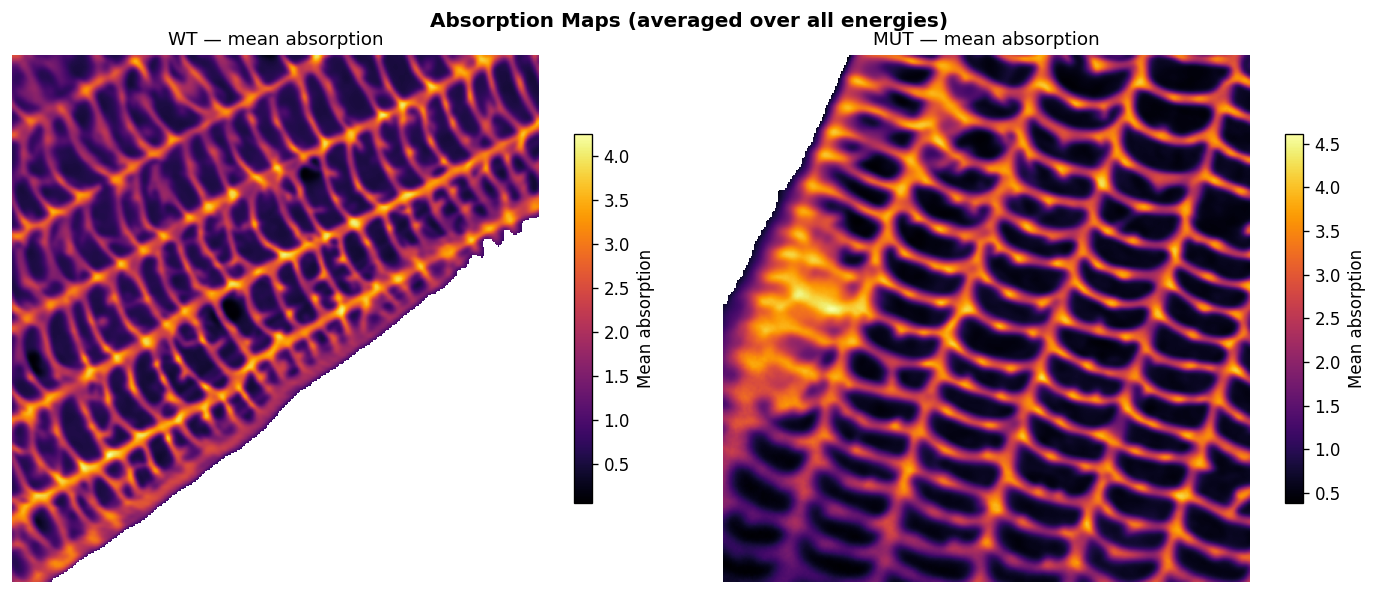

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, dname in zip(axes, ["WT", "MUT"]):
    d = datasets[dname]
    img = d["avg_absorbance"].copy()
    img[d["bg_mask"]] = np.nan
    im = ax.imshow(img, cmap="inferno", origin="lower")
    plt.colorbar(im, ax=ax, shrink=0.7, label="Mean absorption")
    ax.set_title(f"{dname} — mean absorption")
    ax.axis("off")
fig.suptitle("Absorption Maps (averaged over all energies)", fontweight="bold")
fig.tight_layout()
plt.show()

---
## 1. Thickness Distribution (Label-Free)

Absorption at the main edge (290 eV) is proportional to sample thickness.
Comparing the **pixel-wise distribution** of absorption values for WT vs MUT
reveals whether one wing is systematically thicker/thinner or has a broader
range of thicknesses.

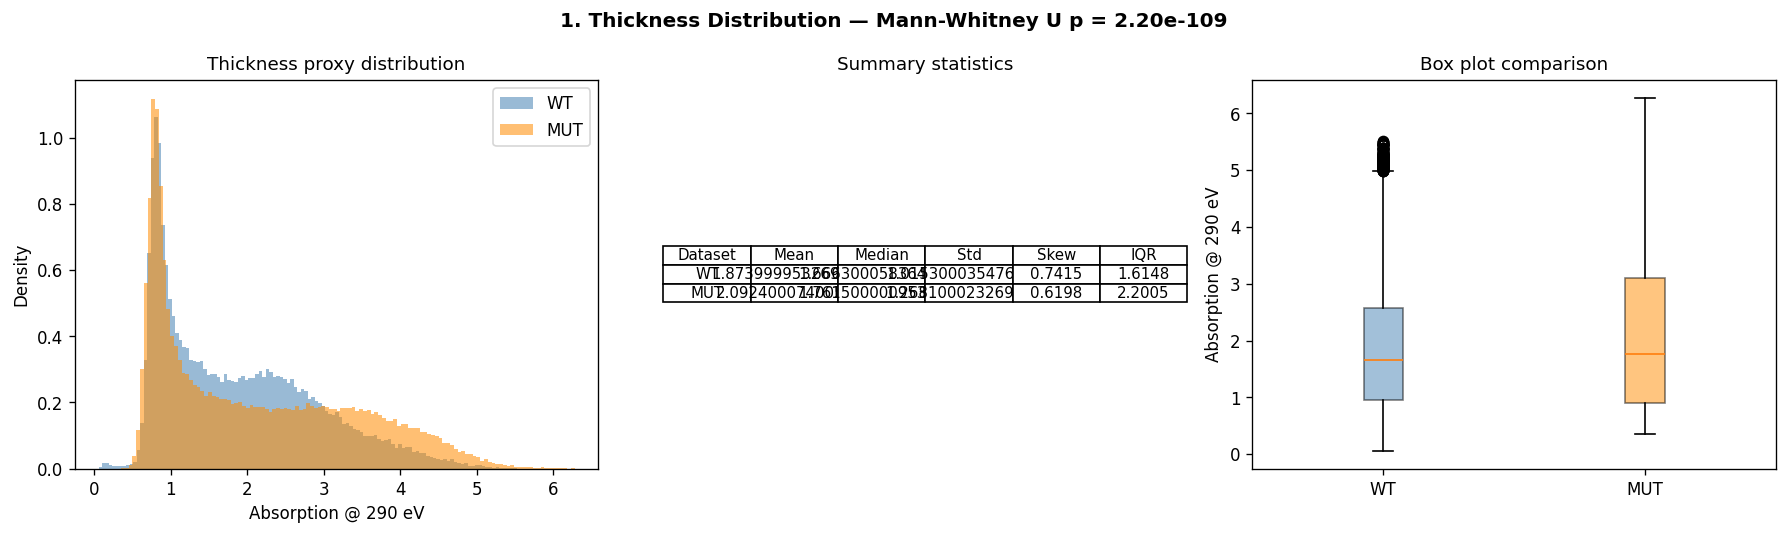

Mann-Whitney U test: U = 4541404184, p = 2.20e-109
  WT  mean = 1.8740, std = 1.0153
  MUT mean = 2.0924, std = 1.2681


In [7]:
eidx_290 = {}
abs_fg = {}
for dname, d in datasets.items():
    eidx = int(np.argmin(np.abs(d["energy"] - 290.0)))
    eidx_290[dname] = eidx
    arr = d["absorption_masked"][eidx]
    vals = arr[d["foreground_mask"] & np.isfinite(arr)]
    abs_fg[dname] = vals

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes[0]
for dname, color in [("WT", "steelblue"), ("MUT", "darkorange")]:
    ax.hist(abs_fg[dname], bins=120, density=True, alpha=0.55, color=color, label=dname)
ax.set_xlabel("Absorption @ 290 eV")
ax.set_ylabel("Density")
ax.set_title("Thickness proxy distribution")
ax.legend()

ax = axes[1]
stats_rows = []
for dname in ["WT", "MUT"]:
    v = abs_fg[dname]
    row = {"Dataset": dname, "Mean": v.mean(), "Median": np.median(v),
           "Std": v.std(), "Skew": float(stats.skew(v)),
           "IQR": float(np.percentile(v, 75) - np.percentile(v, 25))}
    stats_rows.append(row)
df_stats = pd.DataFrame(stats_rows)
ax.axis("off")
tbl = ax.table(cellText=df_stats.round(4).values,
               colLabels=df_stats.columns, loc="center", cellLoc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
ax.set_title("Summary statistics")

ax = axes[2]
bp = ax.boxplot([abs_fg["WT"], abs_fg["MUT"]], labels=["WT", "MUT"],
                patch_artist=True)
colors = ["steelblue", "darkorange"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
ax.set_ylabel("Absorption @ 290 eV")
ax.set_title("Box plot comparison")
ax.set_ylabel("Absorption @ 290 eV")
ax.set_title("Box plot comparison")

t_stat, p_val = stats.mannwhitneyu(abs_fg["WT"], abs_fg["MUT"], alternative="two-sided")
fig.suptitle(f"1. Thickness Distribution — Mann-Whitney U p = {p_val:.2e}", fontweight="bold")
fig.tight_layout()
plt.show()

print(f"Mann-Whitney U test: U = {t_stat:.0f}, p = {p_val:.2e}")
print(f"  WT  mean = {abs_fg['WT'].mean():.4f}, std = {abs_fg['WT'].std():.4f}")
print(f"  MUT mean = {abs_fg['MUT'].mean():.4f}, std = {abs_fg['MUT'].std():.4f}")

---
## 2. 2-D FFT & Radial Power Spectrum (Label-Free)

Periodic micro-structures (ridges, cross-ribs) show up as peaks in the
**radial power spectrum** of the absorption image.  Differences in peak
frequency or power between WT and MUT reveal differences in structural
spacing or regularity.

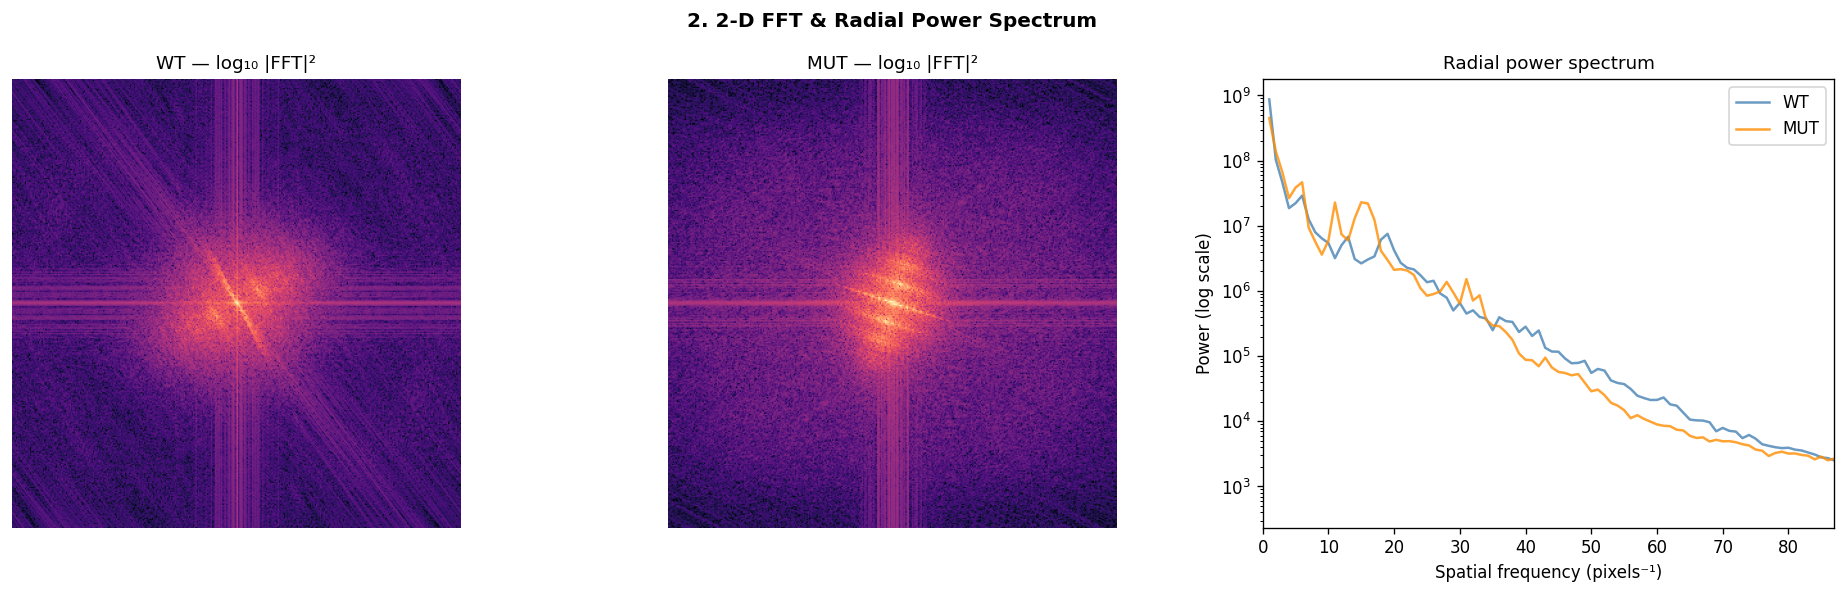

In [8]:
def radial_power_spectrum(img_2d, fg_mask):
    """Compute radial-average of 2D power spectrum.
    Pixels outside fg_mask are zero-padded (mean-subtracted first).
    """
    arr = np.where(fg_mask & np.isfinite(img_2d), img_2d, 0.0)
    arr = arr - arr[fg_mask].mean()
    f2 = np.fft.fftshift(np.abs(np.fft.fft2(arr)) ** 2)
    cy, cx = np.array(f2.shape) // 2
    Y, X = np.ogrid[:f2.shape[0], :f2.shape[1]]
    r = np.sqrt((X - cx) ** 2 + (Y - cy) ** 2).astype(int)
    r_max = min(cx, cy)
    radial = np.zeros(r_max)
    for ri in range(r_max):
        mask_r = r == ri
        if mask_r.any():
            radial[ri] = f2[mask_r].mean()
    return radial


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

rps = {}
for i, dname in enumerate(["WT", "MUT"]):
    d = datasets[dname]
    img = d["absorption_masked"][eidx_290[dname]].copy()
    img_clean = np.where(d["foreground_mask"] & np.isfinite(img), img, 0.0)
    img_clean = img_clean - img_clean[d["foreground_mask"]].mean()

    ps2d = np.fft.fftshift(np.abs(np.fft.fft2(img_clean)) ** 2)
    axes[i].imshow(np.log10(ps2d + 1), cmap="magma", origin="lower")
    axes[i].set_title(f"{dname} — log₁₀ |FFT|²")
    axes[i].axis("off")

    rps[dname] = radial_power_spectrum(d["absorption_masked"][eidx_290[dname]],
                                      d["foreground_mask"])

ax = axes[2]
for dname, color in [("WT", "steelblue"), ("MUT", "darkorange")]:
    r = rps[dname]
    freqs = np.arange(len(r))
    ax.semilogy(freqs[1:], r[1:], color=color, alpha=0.8, label=dname)
ax.set_xlabel("Spatial frequency (pixels⁻¹)")
ax.set_ylabel("Power (log scale)")
ax.set_title("Radial power spectrum")
ax.legend()
ax.set_xlim(0, min(len(rps["WT"]), len(rps["MUT"])) // 2)

fig.suptitle("2. 2-D FFT & Radial Power Spectrum", fontweight="bold")
fig.tight_layout()
plt.show()

---
## 3. GLCM Texture Features (Label-Free)

Gray-Level Co-occurrence Matrix (GLCM) captures spatial texture properties.  
We compute 4 standard features at multiple distances and directions, then
compare WT vs MUT.

- **Contrast**: local intensity variation (higher → rougher)
- **Homogeneity**: closeness of elements to diagonal (higher → smoother)
- **Energy / ASM**: uniformity of gray-level pairs
- **Correlation**: linear dependency between gray-level pairs

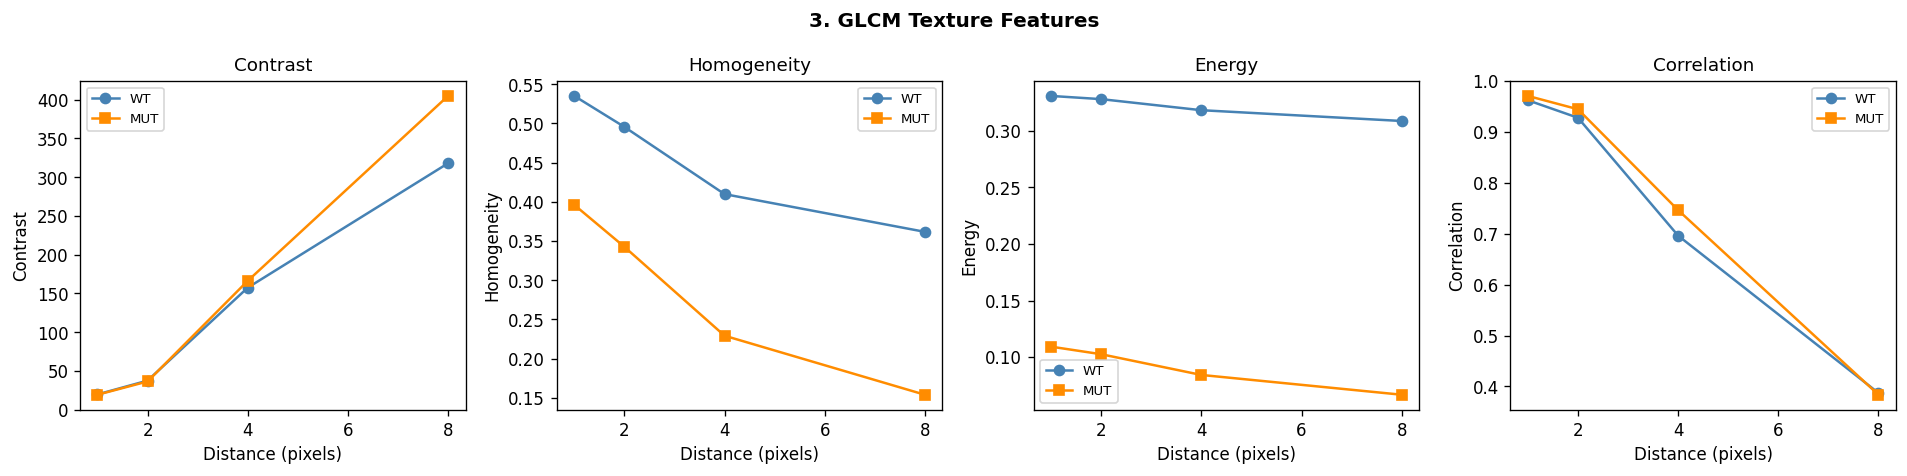

GLCM summary (averaged over all distances & angles):
  contrast       : WT=133.0792, MUT=156.6390, Δ=+17.7%
  homogeneity    : WT=0.4505, MUT=0.2804, Δ=-37.8%
  energy         : WT=0.3215, MUT=0.0906, Δ=-71.8%
  correlation    : WT=0.7433, MUT=0.7613, Δ=+2.4%


In [9]:
def compute_glcm_features(img_2d, fg_mask, n_levels=64, distances=None, angles=None):
    """Compute GLCM features on foreground region of a 2D absorption image."""
    if distances is None:
        distances = [1, 2, 4, 8]
    if angles is None:
        angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]

    arr = img_2d.copy()
    arr[~fg_mask | ~np.isfinite(arr)] = 0.0
    vmin, vmax = np.percentile(arr[fg_mask & np.isfinite(img_2d)], [1, 99])
    arr = np.clip(arr, vmin, vmax)
    arr = ((arr - vmin) / (vmax - vmin + 1e-8) * (n_levels - 1)).astype(np.uint8)

    glcm = graycomatrix(arr, distances=distances, angles=angles,
                        levels=n_levels, symmetric=True, normed=True)

    features = {}
    for prop in ["contrast", "homogeneity", "energy", "correlation"]:
        vals = graycoprops(glcm, prop)
        features[prop] = vals.mean(axis=1)  # average over angles → per distance
    return features, distances


glcm_results = {}
for dname in ["WT", "MUT"]:
    d = datasets[dname]
    img = d["absorption_masked"][eidx_290[dname]]
    glcm_results[dname], dists = compute_glcm_features(img, d["foreground_mask"])

props = ["contrast", "homogeneity", "energy", "correlation"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, prop in zip(axes, props):
    for dname, color, marker in [("WT", "steelblue", "o"), ("MUT", "darkorange", "s")]:
        ax.plot(dists, glcm_results[dname][prop], color=color, marker=marker,
                label=dname, linewidth=1.5)
    ax.set_xlabel("Distance (pixels)")
    ax.set_ylabel(prop.capitalize())
    ax.set_title(prop.capitalize())
    ax.legend(fontsize=8)

fig.suptitle("3. GLCM Texture Features", fontweight="bold")
fig.tight_layout()
plt.show()

print("GLCM summary (averaged over all distances & angles):")
for prop in props:
    wt_val = glcm_results["WT"][prop].mean()
    mut_val = glcm_results["MUT"][prop].mean()
    diff_pct = (mut_val - wt_val) / (wt_val + 1e-8) * 100
    print(f"  {prop:15s}: WT={wt_val:.4f}, MUT={mut_val:.4f}, Δ={diff_pct:+.1f}%")

---
## 4. Gradient / Edge Density (Label-Free)

The Sobel gradient magnitude highlights structural boundaries.  
Comparing the **distribution of gradient magnitudes** and the **fraction
of high-gradient pixels** (edge density) tells us whether one wing has
sharper/more abundant structural boundaries.

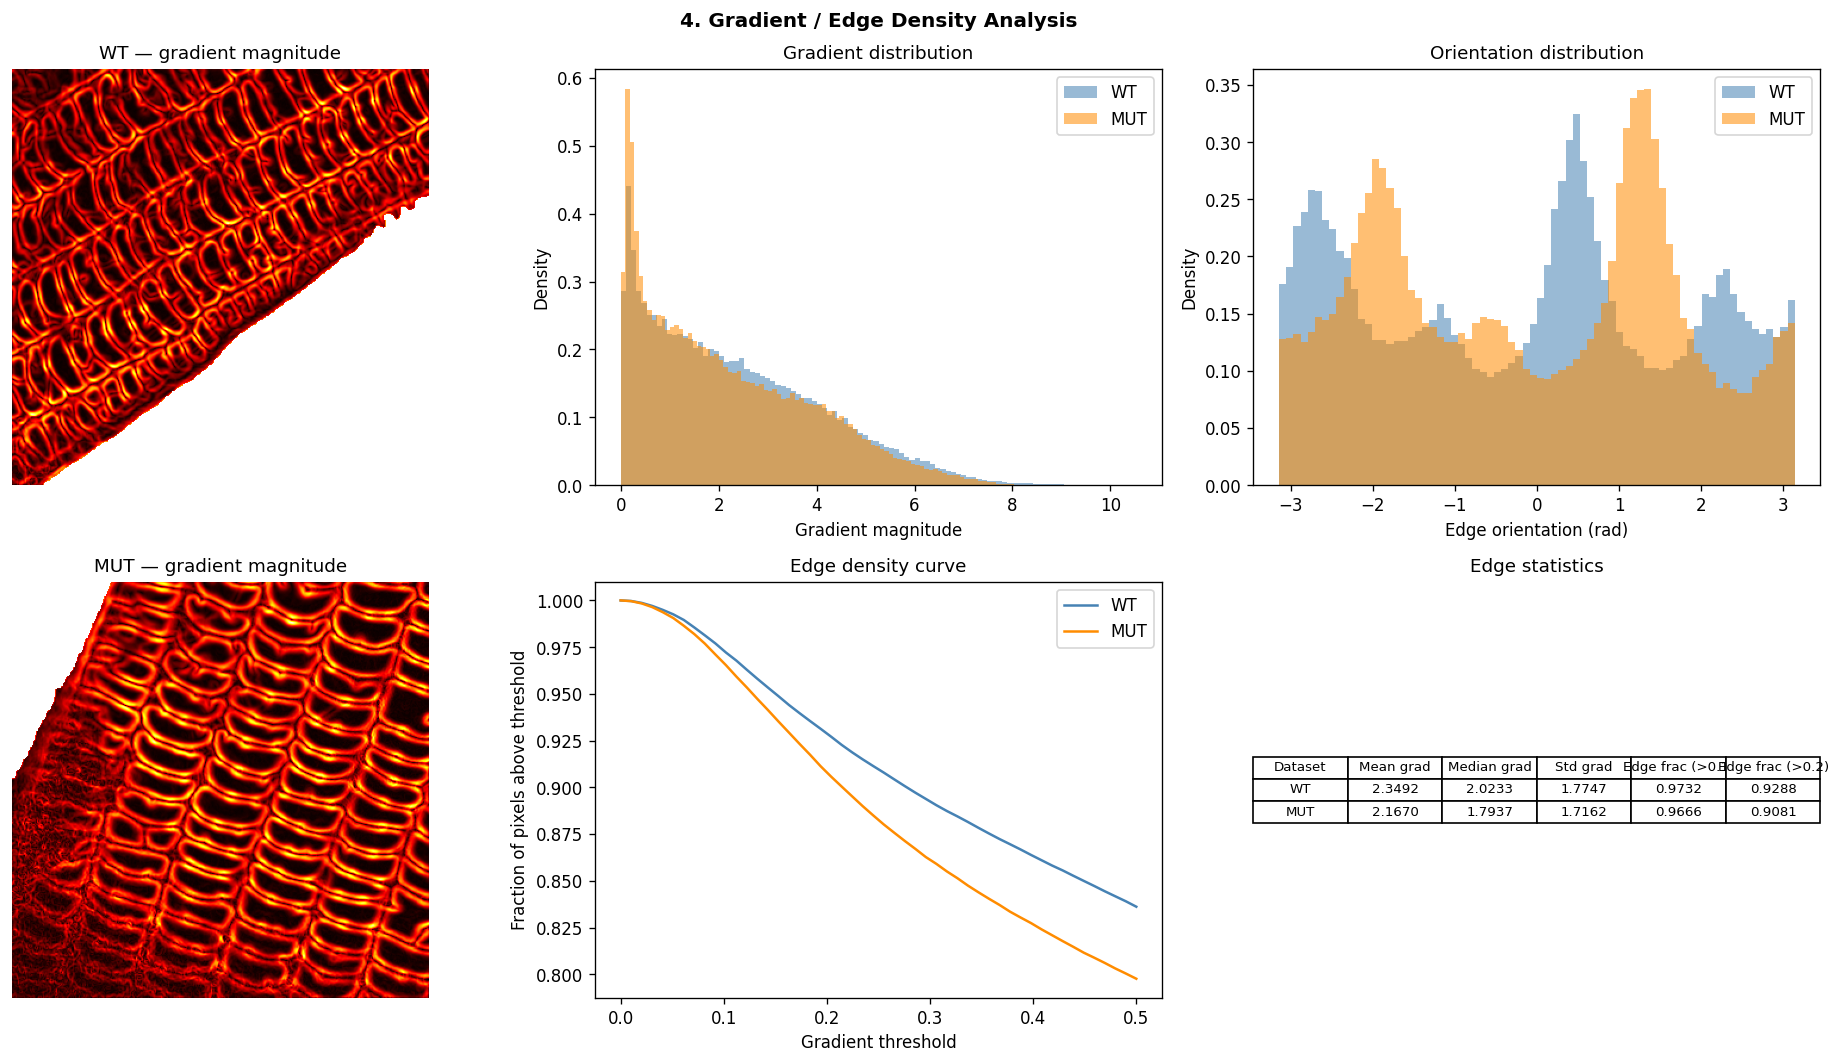

In [10]:
from scipy.ndimage import sobel as ndimage_sobel


def gradient_magnitude(img_2d, fg_mask):
    arr = np.where(fg_mask & np.isfinite(img_2d), img_2d, 0.0)
    gx = ndimage_sobel(arr, axis=1)
    gy = ndimage_sobel(arr, axis=0)
    mag = np.sqrt(gx**2 + gy**2)
    orientation = np.arctan2(gy, gx)
    return mag, orientation


grad_data = {}
for dname in ["WT", "MUT"]:
    d = datasets[dname]
    img = d["absorption_masked"][eidx_290[dname]]
    mag, ori = gradient_magnitude(img, d["foreground_mask"])
    fg = d["foreground_mask"]
    grad_data[dname] = {
        "mag": mag, "ori": ori,
        "fg_vals": mag[fg & np.isfinite(img)],
        "ori_vals": ori[fg & np.isfinite(img)],
    }

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for i, dname in enumerate(["WT", "MUT"]):
    d = datasets[dname]
    mag = grad_data[dname]["mag"].copy()
    mag[~d["foreground_mask"]] = np.nan
    axes[i, 0].imshow(mag, cmap="hot", origin="lower")
    axes[i, 0].set_title(f"{dname} — gradient magnitude")
    axes[i, 0].axis("off")

ax = axes[0, 1]
for dname, color in [("WT", "steelblue"), ("MUT", "darkorange")]:
    vals = grad_data[dname]["fg_vals"]
    ax.hist(vals, bins=100, density=True, alpha=0.55, color=color, label=dname)
ax.set_xlabel("Gradient magnitude")
ax.set_ylabel("Density")
ax.set_title("Gradient distribution")
ax.legend()

ax = axes[0, 2]
for dname, color in [("WT", "steelblue"), ("MUT", "darkorange")]:
    vals = grad_data[dname]["ori_vals"]
    ax.hist(vals, bins=72, density=True, alpha=0.55, color=color, label=dname)
ax.set_xlabel("Edge orientation (rad)")
ax.set_ylabel("Density")
ax.set_title("Orientation distribution")
ax.legend()

thresholds = np.linspace(0, 0.5, 50)
ax = axes[1, 1]
for dname, color in [("WT", "steelblue"), ("MUT", "darkorange")]:
    vals = grad_data[dname]["fg_vals"]
    fracs = [(vals > t).mean() for t in thresholds]
    ax.plot(thresholds, fracs, color=color, label=dname, linewidth=1.5)
ax.set_xlabel("Gradient threshold")
ax.set_ylabel("Fraction of pixels above threshold")
ax.set_title("Edge density curve")
ax.legend()

ax = axes[1, 2]
edge_stats = []
for dname in ["WT", "MUT"]:
    v = grad_data[dname]["fg_vals"]
    edge_stats.append({
        "Dataset": dname,
        "Mean grad": f"{v.mean():.4f}",
        "Median grad": f"{np.median(v):.4f}",
        "Std grad": f"{v.std():.4f}",
        "Edge frac (>0.1)": f"{(v > 0.1).mean():.4f}",
        "Edge frac (>0.2)": f"{(v > 0.2).mean():.4f}",
    })
df_edge = pd.DataFrame(edge_stats)
ax.axis("off")
tbl = ax.table(cellText=df_edge.values, colLabels=df_edge.columns,
               loc="center", cellLoc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(8)
ax.set_title("Edge statistics")

axes[1, 0].axis("off")

fig.suptitle("4. Gradient / Edge Density Analysis", fontweight="bold")
fig.tight_layout()
plt.show()

---
## 5. Local Variance — Roughness Map (Label-Free)

Local variance within a sliding window measures **spatial roughness**.  
Smooth areas (e.g. thick lamina) have low local variance; textured areas
(cross-ribs, ridges) have high local variance.

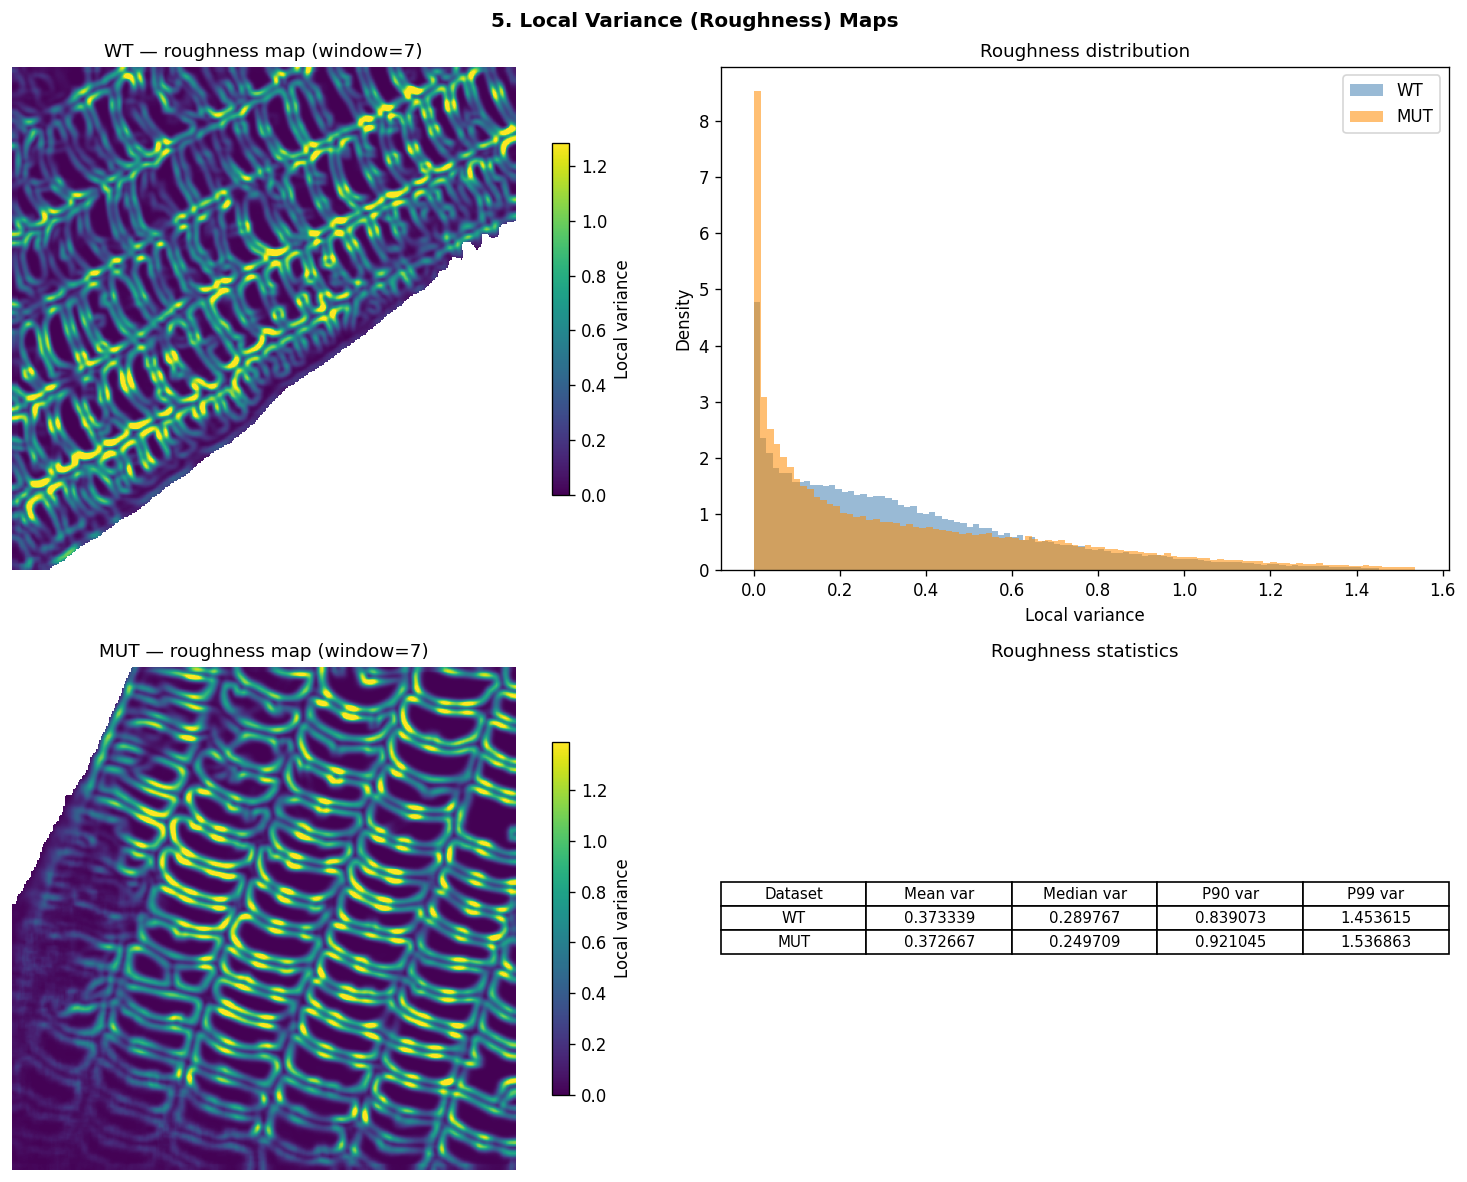

In [11]:
def local_variance_map(img_2d, fg_mask, window_size=7):
    arr = np.where(fg_mask & np.isfinite(img_2d), img_2d, 0.0).astype(np.float64)
    cnt = np.where(fg_mask & np.isfinite(img_2d), 1.0, 0.0)

    sum1 = uniform_filter(arr, size=window_size, mode="constant")
    sum2 = uniform_filter(arr**2, size=window_size, mode="constant")
    cnt_f = uniform_filter(cnt, size=window_size, mode="constant")

    safe = cnt_f > 0.3
    mean_local = np.where(safe, sum1 / np.maximum(cnt_f, 1e-8), 0.0)
    var_local = np.where(safe, sum2 / np.maximum(cnt_f, 1e-8) - mean_local**2, 0.0)
    var_local = np.maximum(var_local, 0.0)
    var_local[~fg_mask] = np.nan
    return var_local


fig, axes = plt.subplots(2, 2, figsize=(13, 10))

var_fg = {}
for i, dname in enumerate(["WT", "MUT"]):
    d = datasets[dname]
    img = d["absorption_masked"][eidx_290[dname]]
    lv = local_variance_map(img, d["foreground_mask"], window_size=7)
    var_fg[dname] = lv[d["foreground_mask"] & np.isfinite(lv)]

    ax = axes[i, 0]
    vmax = np.nanpercentile(lv[d["foreground_mask"]], 98)
    im = ax.imshow(lv, cmap="viridis", origin="lower", vmin=0, vmax=vmax)
    plt.colorbar(im, ax=ax, shrink=0.7, label="Local variance")
    ax.set_title(f"{dname} — roughness map (window=7)")
    ax.axis("off")

ax = axes[0, 1]
for dname, color in [("WT", "steelblue"), ("MUT", "darkorange")]:
    vmax_plot = np.percentile(var_fg[dname], 99)
    vals = var_fg[dname][var_fg[dname] < vmax_plot]
    ax.hist(vals, bins=100, density=True, alpha=0.55, color=color, label=dname)
ax.set_xlabel("Local variance")
ax.set_ylabel("Density")
ax.set_title("Roughness distribution")
ax.legend()

ax = axes[1, 1]
roughness_stats = []
for dname in ["WT", "MUT"]:
    v = var_fg[dname]
    roughness_stats.append({
        "Dataset": dname,
        "Mean var": f"{v.mean():.6f}",
        "Median var": f"{np.median(v):.6f}",
        "P90 var": f"{np.percentile(v, 90):.6f}",
        "P99 var": f"{np.percentile(v, 99):.6f}",
    })
df_var = pd.DataFrame(roughness_stats)
ax.axis("off")
tbl = ax.table(cellText=df_var.values, colLabels=df_var.columns,
               loc="center", cellLoc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
ax.set_title("Roughness statistics")

fig.suptitle("5. Local Variance (Roughness) Maps", fontweight="bold")
fig.tight_layout()
plt.show()

---
## 6. Multi-Scale Morphological Profile (Label-Free)

Apply **morphological opening** (removes bright features smaller than the
structuring element) at increasing radii.  The difference between the
original and the opened image gives the **morphological profile** — a
measure of how much structural detail exists at each scale.

Comparing WT and MUT profiles reveals whether one has more fine-scale
vs coarse-scale features.

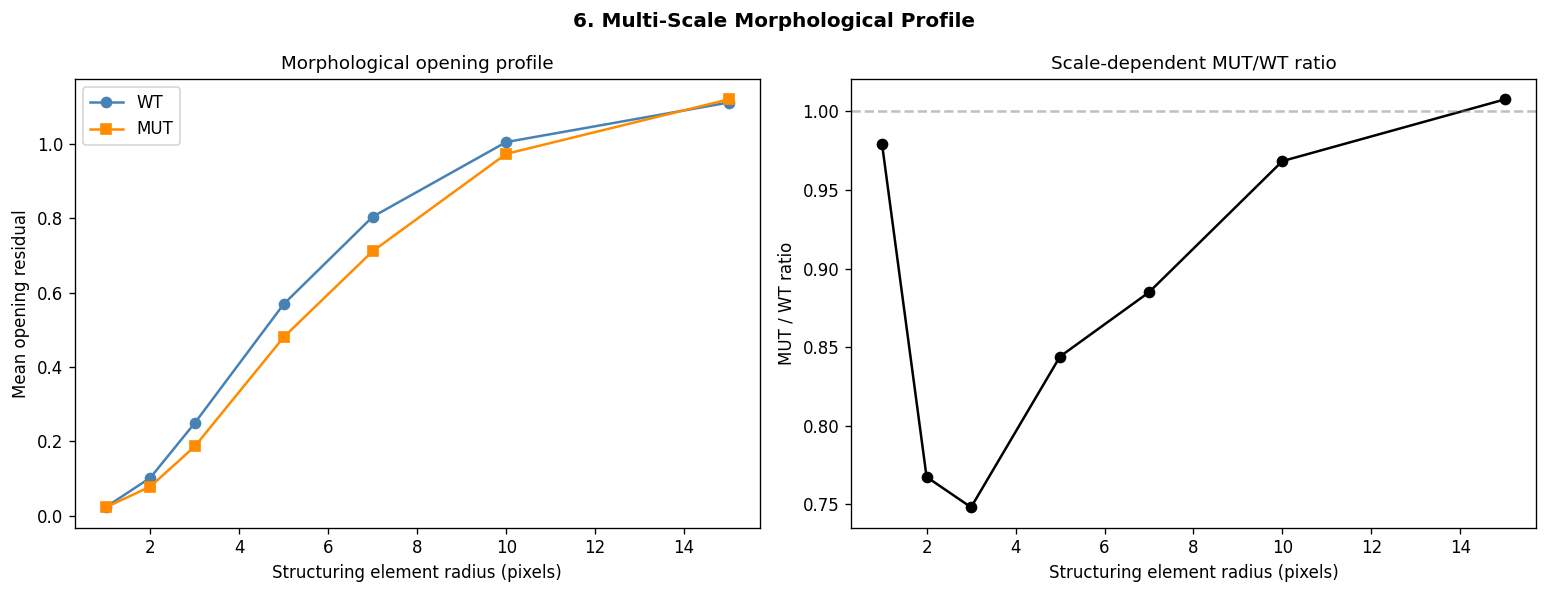

Morphological opening profile (mean residual):
  radius  1: WT=0.02343, MUT=0.02293, ratio=0.979
  radius  2: WT=0.10229, MUT=0.07849, ratio=0.767
  radius  3: WT=0.24948, MUT=0.18661, ratio=0.748
  radius  5: WT=0.56908, MUT=0.48029, ratio=0.844
  radius  7: WT=0.80369, MUT=0.71117, ratio=0.885
  radius 10: WT=1.00421, MUT=0.97246, ratio=0.968
  radius 15: WT=1.11039, MUT=1.11888, ratio=1.008


In [12]:
radii = [1, 2, 3, 5, 7, 10, 15]

morph_profiles = {}
for dname in ["WT", "MUT"]:
    d = datasets[dname]
    img = d["absorption_masked"][eidx_290[dname]].copy()
    img[~d["foreground_mask"] | ~np.isfinite(img)] = 0.0

    profile = []
    for r in radii:
        se = disk(r)
        opened = opening(img, se)
        diff = img - opened
        fg_diff = diff[d["foreground_mask"]]
        profile.append(fg_diff.mean())
    morph_profiles[dname] = np.array(profile)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for dname, color, marker in [("WT", "steelblue", "o"), ("MUT", "darkorange", "s")]:
    ax.plot(radii, morph_profiles[dname], color=color, marker=marker,
            label=dname, linewidth=1.5)
ax.set_xlabel("Structuring element radius (pixels)")
ax.set_ylabel("Mean opening residual")
ax.set_title("Morphological opening profile")
ax.legend()

ax = axes[1]
ratio = morph_profiles["MUT"] / np.maximum(morph_profiles["WT"], 1e-8)
ax.plot(radii, ratio, "k-o", linewidth=1.5)
ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Structuring element radius (pixels)")
ax.set_ylabel("MUT / WT ratio")
ax.set_title("Scale-dependent MUT/WT ratio")

fig.suptitle("6. Multi-Scale Morphological Profile", fontweight="bold")
fig.tight_layout()
plt.show()

print("Morphological opening profile (mean residual):")
for i, r in enumerate(radii):
    print(f"  radius {r:2d}: WT={morph_profiles['WT'][i]:.5f}, "
          f"MUT={morph_profiles['MUT'][i]:.5f}, "
          f"ratio={ratio[i]:.3f}")

---
## 7. Connected-Component Statistics (Label-Dependent)

⚠ **Caveat**: the semantic labels come from independent UMAP+K-means per wing,
so cross-dataset class comparisons must be interpreted carefully.  
However, the **morphological statistics** of connected components (area,
perimeter, eccentricity, solidity) within each wing are still meaningful
and can be compared across wings.

For each semantic class we:
1. Extract connected components
2. Measure shape features (area, eccentricity, solidity, extent)
3. Compare distributions between WT and MUT

In [13]:
def cc_statistics(semantic_map, class_id, min_area=10):
    """Extract connected-component shape statistics for a given class."""
    binary = (semantic_map == class_id).astype(np.uint8)
    labeled, n_cc = ndi_label(binary)
    if n_cc == 0:
        return pd.DataFrame()
    props = regionprops_table(labeled, properties=[
        "area", "eccentricity", "solidity", "extent", "perimeter",
        "major_axis_length", "minor_axis_length",
    ])
    df = pd.DataFrame(props)
    df = df[df["area"] >= min_area].reset_index(drop=True)
    return df


cc_all = {}
for dname in ["WT", "MUT"]:
    sem = datasets[dname]["semantic_full"]
    for cid, cname in CLASS_NAMES.items():
        df = cc_statistics(sem, cid, min_area=10)
        df.insert(0, "class", cname)
        df.insert(0, "dataset", dname)
        cc_all[(dname, cid)] = df

cc_df = pd.concat(cc_all.values(), ignore_index=True)
print(f"Total connected components (area >= 10): {len(cc_df)}")
print(cc_df.groupby(["dataset", "class"])["area"].describe().round(1))

Total connected components (area >= 10): 1049
                             count    mean     std   min   25%   50%   75%  \
dataset class                                                                
MUT     Cross Ribs & Ridges  361.0    72.6   143.7  10.0  15.0  25.0  73.0   
        Lower Lamina          62.0  1030.6  7438.0  10.0  19.2  40.5  87.5   
        Trabeculae            63.0    69.7   383.4  10.0  12.0  17.0  24.0   
WT      Cross Ribs & Ridges  358.0    72.6   123.1  10.0  15.0  32.0  83.0   
        Lower Lamina         137.0   321.4  2912.7  10.0  17.0  35.0  79.0   
        Trabeculae            68.0    18.2    10.4  10.0  11.0  13.5  21.8   

                                 max  
dataset class                         
MUT     Cross Ribs & Ridges   1832.0  
        Lower Lamina         58638.0  
        Trabeculae            3061.0  
WT      Cross Ribs & Ridges   1234.0  
        Lower Lamina         34142.0  
        Trabeculae              56.0  


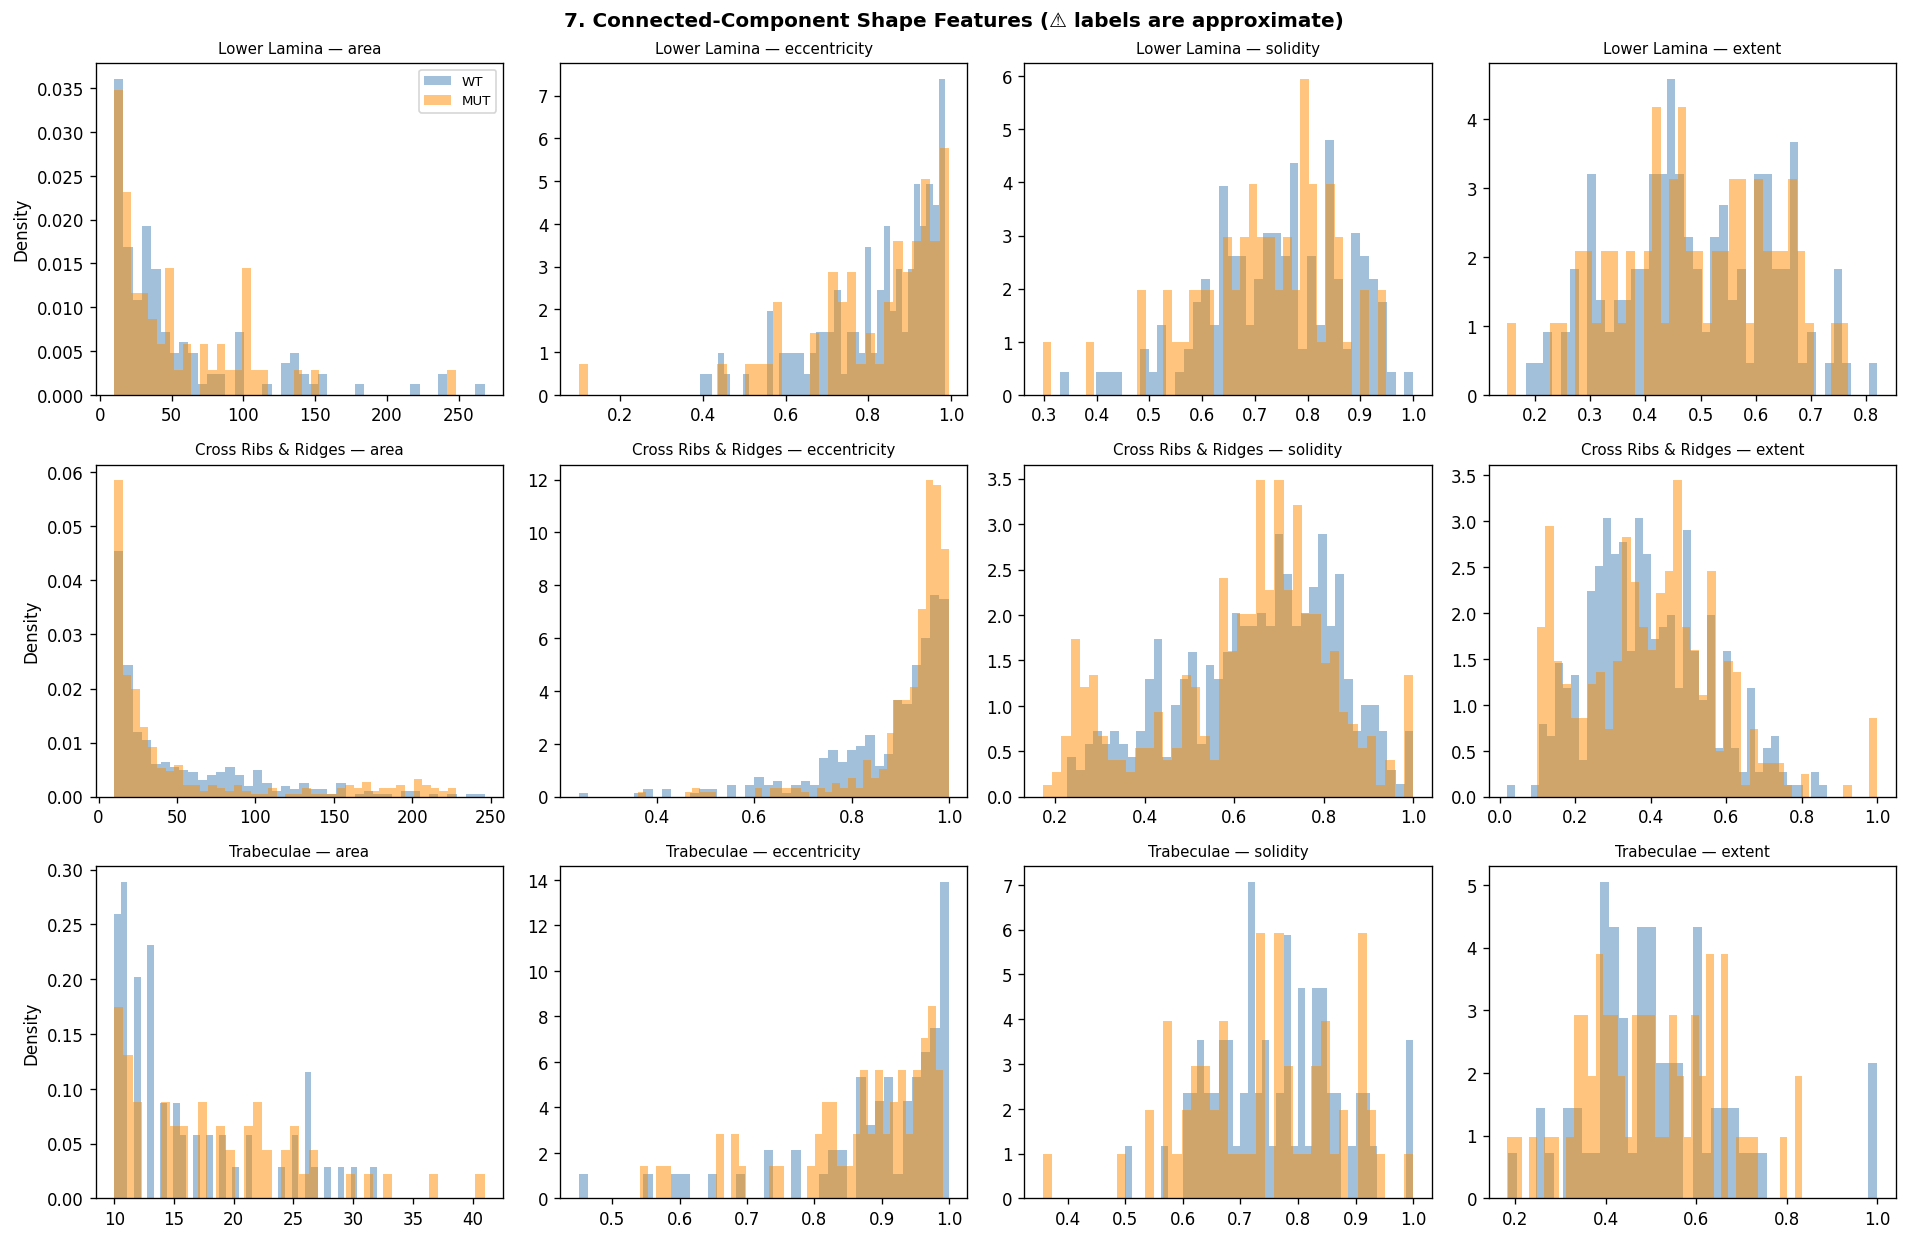

In [14]:
shape_features = ["area", "eccentricity", "solidity", "extent"]

fig, axes = plt.subplots(len(CLASS_NAMES), len(shape_features),
                         figsize=(16, 3.5 * len(CLASS_NAMES)))

for row, (cid, cname) in enumerate(CLASS_NAMES.items()):
    for col, feat in enumerate(shape_features):
        ax = axes[row, col]
        for dname, color in [("WT", "steelblue"), ("MUT", "darkorange")]:
            vals = cc_all[(dname, cid)][feat].values
            if len(vals) == 0:
                continue
            if feat == "area":
                vmax = np.percentile(vals, 95)
                vals = vals[vals < vmax]
            ax.hist(vals, bins=40, density=True, alpha=0.5, color=color, label=dname)
        ax.set_title(f"{cname} — {feat}", fontsize=9)
        if col == 0:
            ax.set_ylabel("Density")
        if row == 0 and col == 0:
            ax.legend(fontsize=8)

fig.suptitle("7. Connected-Component Shape Features (⚠ labels are approximate)",
             fontweight="bold")
fig.tight_layout()
plt.show()

In [15]:
print("\nStatistical tests on CC shape features (Mann-Whitney U):")
print("=" * 75)
test_results = []
for cid, cname in CLASS_NAMES.items():
    for feat in shape_features:
        wt_vals = cc_all[("WT", cid)][feat].values
        mut_vals = cc_all[("MUT", cid)][feat].values
        if len(wt_vals) < 5 or len(mut_vals) < 5:
            continue
        u_stat, p_val = stats.mannwhitneyu(wt_vals, mut_vals, alternative="two-sided")
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
        test_results.append({
            "Class": cname, "Feature": feat,
            "WT median": np.median(wt_vals),
            "MUT median": np.median(mut_vals),
            "U": u_stat, "p-value": p_val, "Sig": sig,
        })

df_tests = pd.DataFrame(test_results)
print(df_tests.to_string(index=False, float_format="{:.4f}".format))


Statistical tests on CC shape features (Mann-Whitney U):
              Class      Feature  WT median  MUT median          U  p-value Sig
       Lower Lamina         area    35.0000     40.5000  4095.5000   0.6881    
       Lower Lamina eccentricity     0.8616      0.8767  4110.0000   0.7168    
       Lower Lamina     solidity     0.7561      0.7338  4611.5000   0.3333    
       Lower Lamina       extent     0.4792      0.4910  4190.0000   0.8806    
Cross Ribs & Ridges         area    32.0000     25.0000 68842.5000   0.1292    
Cross Ribs & Ridges eccentricity     0.9225      0.9540 48205.0000   0.0000 ***
Cross Ribs & Ridges     solidity     0.6772      0.6591 69311.0000   0.0920    
Cross Ribs & Ridges       extent     0.3758      0.4074 63285.0000   0.6320    
         Trabeculae         area    13.5000     17.0000  1811.0000   0.1268    
         Trabeculae eccentricity     0.9341      0.8987  2599.0000   0.0355   *
         Trabeculae     solidity     0.7656      0.7419  2308.

---
## 8. Summary: Consolidated Evidence Table

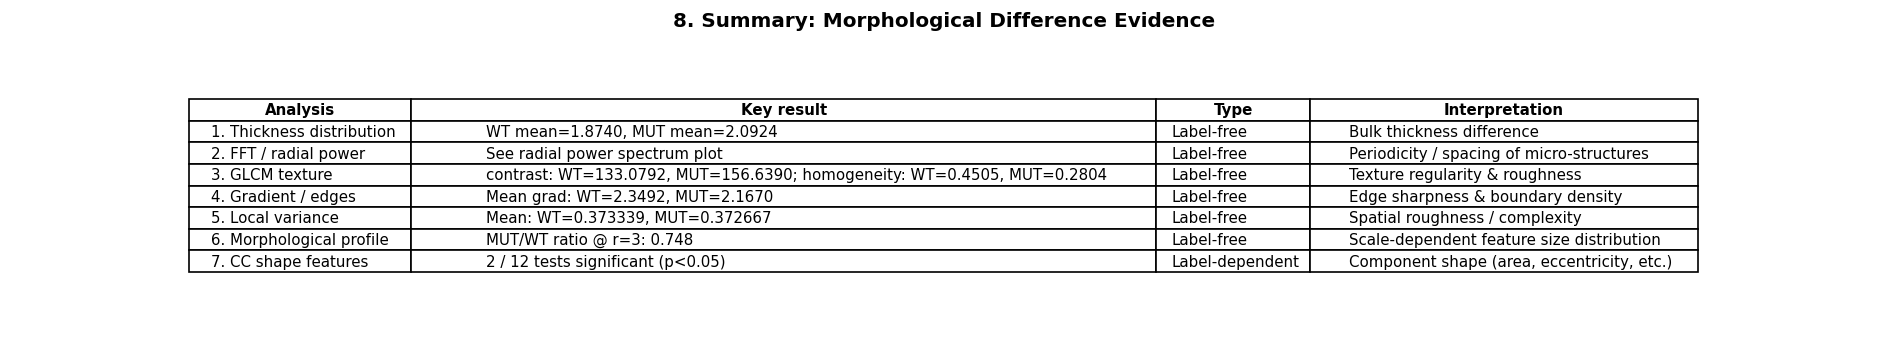


All analyses complete.
Sections 1–6 are fully label-free and thus independent of clustering accuracy.
Section 7 uses labels — interpret with caution as noted.


In [16]:
summary = [
    ["1. Thickness distribution",
     f"WT mean={abs_fg['WT'].mean():.4f}, MUT mean={abs_fg['MUT'].mean():.4f}",
     "Label-free",
     "Bulk thickness difference"],
    ["2. FFT / radial power",
     "See radial power spectrum plot",
     "Label-free",
     "Periodicity / spacing of micro-structures"],
    ["3. GLCM texture",
     "; ".join(f"{p}: WT={glcm_results['WT'][p].mean():.4f}, MUT={glcm_results['MUT'][p].mean():.4f}"
              for p in ["contrast", "homogeneity"]),
     "Label-free",
     "Texture regularity & roughness"],
    ["4. Gradient / edges",
     f"Mean grad: WT={grad_data['WT']['fg_vals'].mean():.4f}, MUT={grad_data['MUT']['fg_vals'].mean():.4f}",
     "Label-free",
     "Edge sharpness & boundary density"],
    ["5. Local variance",
     f"Mean: WT={var_fg['WT'].mean():.6f}, MUT={var_fg['MUT'].mean():.6f}",
     "Label-free",
     "Spatial roughness / complexity"],
    ["6. Morphological profile",
     f"MUT/WT ratio @ r=3: {morph_profiles['MUT'][2]/max(morph_profiles['WT'][2],1e-8):.3f}",
     "Label-free",
     "Scale-dependent feature size distribution"],
    ["7. CC shape features",
     f"{len(df_tests[df_tests['Sig'] != ''])} / {len(df_tests)} tests significant (p<0.05)",
     "Label-dependent",
     "Component shape (area, eccentricity, etc.)"],
]

df_summary = pd.DataFrame(summary, columns=["Analysis", "Key result", "Type", "Interpretation"])

fig, ax = plt.subplots(figsize=(16, 3))
ax.axis("off")
tbl = ax.table(cellText=df_summary.values, colLabels=df_summary.columns,
               loc="center", cellLoc="left")
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
tbl.auto_set_column_width([0, 1, 2, 3])
for key, cell in tbl.get_celld().items():
    if key[0] == 0:
        cell.set_text_props(fontweight="bold")
ax.set_title("8. Summary: Morphological Difference Evidence", fontweight="bold", fontsize=12)
fig.tight_layout()
plt.show()

print("\nAll analyses complete.")
print("Sections 1–6 are fully label-free and thus independent of clustering accuracy.")
print("Section 7 uses labels — interpret with caution as noted.")